# Experiment 04: ResNet34-UNet + CLAHE + Strong Augmentation

**Date:** 2025-10-08  
**Author:** CAP5410 Project Team  
**Objective:** Combat overfitting using aggressive data augmentation

---

## 📋 Experiment Overview

### Hypothesis
**Strong data augmentation** will significantly reduce overfitting and improve generalization, closing the gap between training and validation performance.

### Problem Identified in Experiment 03
- ❌ **Training Dice:** 75-85%
- ❌ **Validation Dice:** 66-70%
- ❌ **Gap:** 10-15% (clear overfitting)
- ❌ **Root cause:** Only 400 training samples for 24.5M parameters

### Solution: Strong Augmentation Strategy
1. ✅ **Geometric transforms:** Rotation (±30°), flipping, affine, shear
2. ✅ **Color transforms:** Brightness, contrast, saturation, hue
3. ✅ **Blur/Sharpness:** Gaussian blur, sharpness adjustment
4. ✅ **High probability:** 80% augmentation rate (vs. implicit 0% before)

### Expected Improvement
- **Training Dice:** 70-80% (slightly lower due to harder samples)
- **Validation Dice:** 73-78% (significant improvement!)
- **Gap:** 2-5% (healthy range)

### Configuration
- **Model:** ResNet34-UNet (pretrained encoder)
- **Preprocessing:** CLAHE (LAB mode, clip_limit=2.0)
- **Augmentation:** **STRONG** (p=0.8, geometric+color+blur)
- **Dataset:** REFUGE (cropped masks)
- **Training samples:** 400 (effective: ~2000 with augmentation!)
- **Validation samples:** 400
- **Test samples:** 400

### Hyperparameters
```python
{
    'epochs': 50,
    'freeze_encoder_epochs': 10,
    'batch_size': 8,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'augmentation_type': 'strong',  # NEW!
    'augmentation_p': 0.8,  # NEW!
}
```

---

## 1️⃣ Environment Setup

In [11]:
import sys
import os
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))

print(f"Project root: {project_root}")
print(f"Working directory: {Path.cwd()}")

Project root: /home/robolab/dev/CAP5410-roi-enhancer-odoc
Working directory: /home/robolab/dev/CAP5410-roi-enhancer-odoc/experiments/04_resnet34_augmented


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Project imports
from models.resnet_unet import ResNetUNet
from data_loader.dataset import RetinaDataset, RetinaDatasetTest
from data_loader.strong_augmentation import StrongAugmentation, get_augmentation
from experiments.utils import (
    train_epoch,
    validate_epoch,
    test_model,
    plot_training_curves,
    visualize_predictions,
    visualize_data_samples,
    save_config,
    save_history,
    save_test_results,
    print_test_results,
    print_model_info,
)
from tqdm.notebook import tqdm
from datetime import datetime

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti
Memory: 11.35 GB


## 2️⃣ Augmentation Demo

Let's visualize what strong augmentation does to our images!

✅ Loaded cropped image: 0826_cropped.jpg
   Shape: (494, 432, 3)
   Image tensor shape: torch.Size([3, 494, 432])
   Mask tensor shape: torch.Size([2, 494, 432])


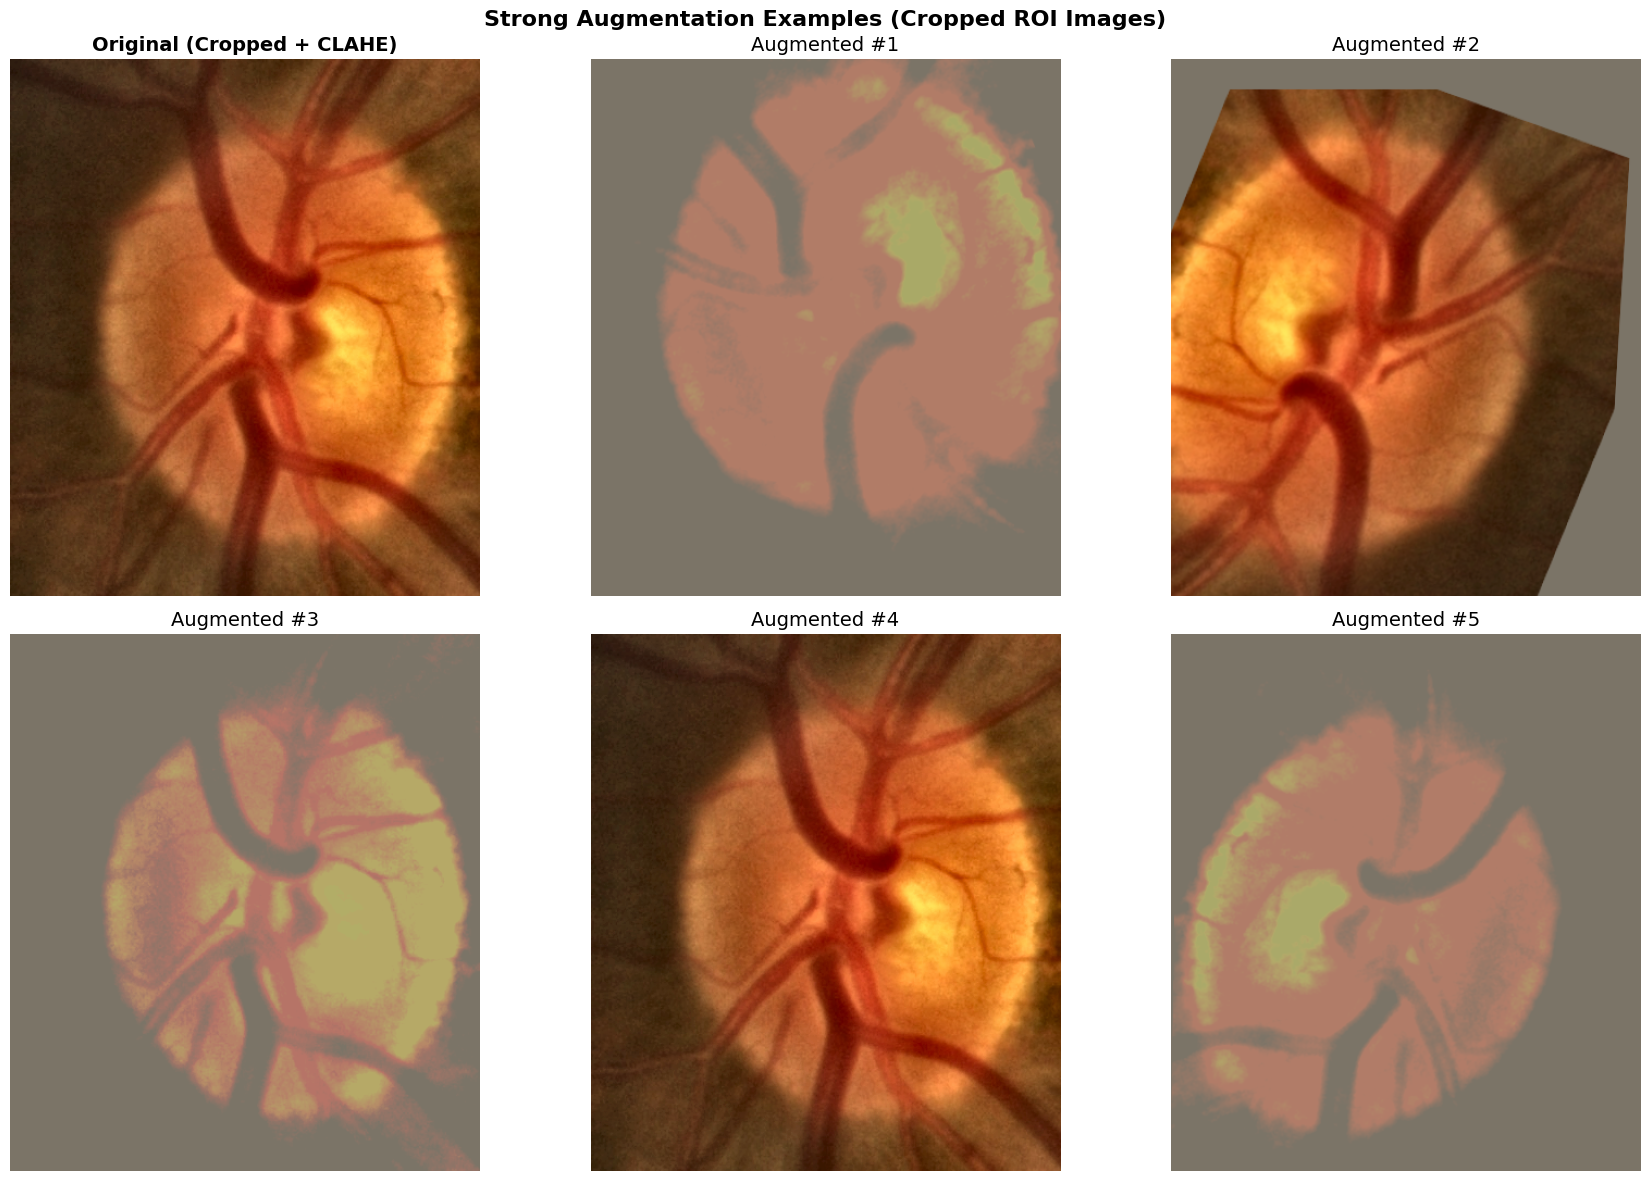


✅ Strong augmentation applies:
   - Random rotation (±30°)
   - Random flipping (horizontal/vertical)
   - Random affine (translate, scale, shear)
   - Color jitter (brightness, contrast, saturation, hue)
   - Gaussian blur or sharpness adjustment
   - Applied with 80% probability during training!

💡 Note: Using ACTUAL cropped ROI images (494x432) from REFUGE_cropped_masks!


In [13]:
# Load a sample for augmentation demo
from PIL import Image
from data_loader.clahe_preprocessing import CLAHEPreprocessor
import torchvision.transforms as transforms

# Load sample CROPPED image from the CORRECT location (REFUGE_cropped_masks, not Training-400!)
sample_path = project_root / 'datasets' / 'REFUGE_cropped_masks' / '0826' / '0826_cropped.jpg'
sample_img = np.array(Image.open(sample_path))

print(f"✅ Loaded cropped image: {sample_path.name}")
print(f"   Shape: {sample_img.shape}")

# Apply CLAHE (CLAHEPreprocessor is callable, use __call__ not .apply())
clahe = CLAHEPreprocessor(clip_limit=2.0, apply_to='LAB')
clahe_img = clahe(sample_img)  # Call the object directly

# Convert to tensor
to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
img_tensor = normalize(to_tensor(clahe_img))

print(f"   Image tensor shape: {img_tensor.shape}")

# Create dummy mask with SAME spatial dimensions as image
_, H, W = img_tensor.shape
mask_tensor = torch.rand(2, H, W)  # Match the height and width of the image

print(f"   Mask tensor shape: {mask_tensor.shape}")

# Apply augmentation 5 times
augmentor = StrongAugmentation(p=1.0)  # Always augment for demo

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Original (CLAHE-enhanced)
img_np = img_tensor.numpy().transpose(1, 2, 0)
img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_np = np.clip(img_np, 0, 1)
axes[0, 0].imshow(img_np)
axes[0, 0].set_title('Original (Cropped + CLAHE)', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# 5 augmented versions
for idx in range(5):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    
    aug_img, aug_mask = augmentor(img_tensor.clone(), mask_tensor.clone())
    
    # Denormalize
    aug_np = aug_img.numpy().transpose(1, 2, 0)
    aug_np = aug_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    aug_np = np.clip(aug_np, 0, 1)
    
    axes[row, col].imshow(aug_np)
    axes[row, col].set_title(f'Augmented #{idx+1}', fontsize=14)
    axes[row, col].axis('off')

plt.suptitle('Strong Augmentation Examples (Cropped ROI Images)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Strong augmentation applies:")
print("   - Random rotation (±30°)")
print("   - Random flipping (horizontal/vertical)")
print("   - Random affine (translate, scale, shear)")
print("   - Color jitter (brightness, contrast, saturation, hue)")
print("   - Gaussian blur or sharpness adjustment")
print("   - Applied with 80% probability during training!")
print(f"\n💡 Note: Using ACTUAL cropped ROI images ({H}x{W}) from REFUGE_cropped_masks!")

## 3️⃣ Configuration

In [14]:
# Experiment configuration
CONFIG = {
    # Model
    'model': 'resnet34_unet_augmented',
    'encoder': 'resnet34',
    'pretrained': True,
    
    # Data
    'data_dir': '../../datasets/REFUGE',
    'train_csv': '../../datasets/REFUGE/REFUGETrain.csv',
    'val_csv': '../../datasets/REFUGE/REFUGE1Val.csv',
    'test_csv': '../../datasets/REFUGE/REFUGE1Test.csv',
    'use_cropped': True,
    'use_clahe': True,
    
    # CLAHE parameters
    'clahe_clip_limit': 2.0,
    'clahe_tile_size': (8, 8),
    'clahe_mode': 'LAB',
    
    # Augmentation - KEY DIFFERENCE!
    'use_augmentation': True,  # NEW!
    'augmentation_type': 'strong',  # NEW! ('none', 'medium', 'strong')
    'augmentation_p': 0.8,  # NEW! (80% of samples will be augmented)
    
    # Training
    'epochs': 50,
    'freeze_encoder_epochs': 10,
    'batch_size': 8,  # REDUCED from 8 to 4 due to augmentation overhead
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'num_workers': 4,
    
    # Output
    'output_dir': './results',
}

# Create output directory
os.makedirs(CONFIG['output_dir'], exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/visualizations", exist_ok=True)

# Save configuration
save_config(CONFIG, f"{CONFIG['output_dir']}/config.json")

print("🚀 KEY DIFFERENCES FROM EXPERIMENT 03:")
print(f"   Augmentation: {CONFIG['augmentation_type'].upper()}")
print(f"   Augmentation probability: {CONFIG['augmentation_p']*100:.0f}%")
print(f"   Batch size: {CONFIG['batch_size']} (reduced from 8 for augmentation)")
print(f"   Effective training samples: ~{400 * 5} (with augmentation variations)")

✅ Configuration saved to ./results/config.json
🚀 KEY DIFFERENCES FROM EXPERIMENT 03:
   Augmentation: STRONG
   Augmentation probability: 80%
   Batch size: 8 (reduced from 8 for augmentation)
   Effective training samples: ~2000 (with augmentation variations)


## 4️⃣ Data Loading with Augmentation

In [15]:
# Create augmentation pipeline
if CONFIG['use_augmentation']:
    train_augmentor = get_augmentation(CONFIG['augmentation_type'])
    print(f"✅ Using {CONFIG['augmentation_type']} augmentation for training")
else:
    train_augmentor = None
    print("⚠️  No augmentation (like Experiment 03)")

# Create datasets
print("\nLoading datasets...")

train_dataset = RetinaDataset(
    csv_file=CONFIG['train_csv'],
    root_dir=CONFIG['data_dir'],
    use_cropped=CONFIG['use_cropped'],
    use_clahe=CONFIG['use_clahe'],
    cropped_masks_dir='../../datasets/REFUGE_cropped_masks',
    augmentation=train_augmentor,  # NEW! Pass augmentation
)

val_dataset = RetinaDataset(
    csv_file=CONFIG['val_csv'],
    root_dir=CONFIG['data_dir'],
    use_cropped=CONFIG['use_cropped'],
    use_clahe=CONFIG['use_clahe'],
    cropped_masks_dir='../../datasets/REFUGE_cropped_masks_val',
    augmentation=None,  # NO augmentation on validation!
)

test_dataset = RetinaDatasetTest(
    csv_file=CONFIG['test_csv'],
    root_dir=CONFIG['data_dir'],
    use_cropped=CONFIG['use_cropped'],
    use_clahe=CONFIG['use_clahe'],
    cropped_masks_dir='../../datasets/REFUGE_cropped_masks_test',
    augmentation=None,  # NO augmentation on test!
)

print(f"✅ Train samples: {len(train_dataset)} (with augmentation)")
print(f"✅ Validation samples: {len(val_dataset)} (no augmentation)")
print(f"✅ Test samples: {len(test_dataset)} (no augmentation)")

✅ Using strong augmentation for training

Loading datasets...
✅ Train samples: 400 (with augmentation)
✅ Validation samples: 400 (no augmentation)
✅ Test samples: 400 (no augmentation)


In [16]:
# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print("✅ Data loaders created")

✅ Data loaders created


## 5️⃣ Model Definition

### ⚠️ Important: Clear GPU Memory First!

If you're getting an **OutOfMemoryError** when creating the model, you need to:

**Option 1: Restart Kernel (RECOMMENDED)**
1. Click `Kernel` → `Restart` in the menu
2. Re-run cells 1-12 (up to and including the data loaders)
3. Then continue with model creation

**Option 2: Kill Previous Process**
Run this command in a terminal:
```bash
nvidia-smi | grep 'python' | awk '{print $5}' | xargs -n1 kill -9
```

Then restart the kernel and re-run the cells above.

In [17]:
# Create model (same as Experiment 03)
model = ResNetUNet(
    backbone=CONFIG['encoder'],
    pretrained=CONFIG['pretrained'],
    n_classes=2
).to(device)

# Print model info
print_model_info(model, title=f"✅ Model created: {CONFIG['model']}")
print("   Note: Same model as Exp 03, but with strong augmentation!")

/home/robolab/dev/CAP5410-roi-enhancer-odoc/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/robolab/dev/CAP5410-roi-enhancer-odoc/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



✅ Model created: resnet34_unet_augmented
  Total parameters: 24,534,946
  Trainable parameters: 24,534,946
   Note: Same model as Exp 03, but with strong augmentation!


In [18]:
# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

print("✅ Loss function and optimizer defined")

✅ Loss function and optimizer defined


## 6️⃣ Two-Stage Training with Augmentation

**Expected behavior with strong augmentation:**
- Training will be **slightly harder** (lower train dice)
- But validation will **improve significantly** (higher val dice)
- **Overfitting gap will close** (train dice ≈ val dice)

In [19]:
# Clear GPU memory before training
import gc
torch.cuda.empty_cache()
gc.collect()

# Check available GPU memory
if torch.cuda.is_available():
    memory_allocated = torch.cuda.memory_allocated(0) / 1e9
    memory_reserved = torch.cuda.memory_reserved(0) / 1e9
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    free_memory = total_memory - memory_allocated
    
    print(f"💾 GPU Memory Status:")
    print(f"   Total: {total_memory:.2f} GB")
    print(f"   Allocated: {memory_allocated:.2f} GB")
    print(f"   Reserved: {memory_reserved:.2f} GB")
    print(f"   Free: {free_memory:.2f} GB")
    print(f"✅ GPU memory cleared and ready for training!")

💾 GPU Memory Status:
   Total: 11.35 GB
   Allocated: 0.30 GB
   Reserved: 0.33 GB
   Free: 11.04 GB
✅ GPU memory cleared and ready for training!


In [ ]:
# Two-stage training with encoder freezing
history = {
    'train_loss': [],
    'train_dice': [],
    'val_loss': [],
    'val_dice': [],
    'val_dice_disc': [],
    'val_dice_cup': [],
}

best_dice = 0.0
start_time = datetime.now()

print(f"\n{'='*60}")
print("Starting TWO-STAGE training WITH STRONG AUGMENTATION...")
print(f"Stage 1: Epochs 0-{CONFIG['freeze_encoder_epochs']-1} (encoder frozen)")
print(f"Stage 2: Epochs {CONFIG['freeze_encoder_epochs']}-{CONFIG['epochs']-1} (full fine-tuning)")
print(f"Augmentation: {CONFIG['augmentation_type']} (p={CONFIG['augmentation_p']})")
print(f"{'='*60}\n")

for epoch in range(CONFIG['epochs']):
    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
    print("-" * 60)
    
    # Freeze/unfreeze encoder
    if epoch == CONFIG['freeze_encoder_epochs']:
        print("\n🔓 UNFREEZING ENCODER - Starting full fine-tuning\n")
        model.unfreeze_encoder()
        print_model_info(model, title="Updated model info")
    elif epoch == 0:
        print("\n🔒 FREEZING ENCODER - Training decoder only\n")
        model.freeze_encoder()
        print_model_info(model, title="Initial model info")
    
    # Train
    train_loss, train_dice = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_metrics = validate_epoch(model, val_loader, criterion, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['val_loss'].append(val_metrics['loss'])
    history['val_dice'].append(val_metrics['dice_mean'])
    history['val_dice_disc'].append(val_metrics['dice_disc'])
    history['val_dice_cup'].append(val_metrics['dice_cup'])
    
    # Calculate overfitting gap
    gap = train_dice - val_metrics['dice_mean']
    
    # Print summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f}")
    print(f"  Val Loss:   {val_metrics['loss']:.4f} | Val Dice:   {val_metrics['dice_mean']:.4f}")
    print(f"  Val Disc:   {val_metrics['dice_disc']:.4f} | Val Cup:    {val_metrics['dice_cup']:.4f}")
    print(f"  Overfitting Gap: {gap:.4f} ({gap*100:.1f}%)")
    
    # Evaluate gap
    if gap < 0.05:
        print(f"  ✅ Healthy gap (< 5%)")
    elif gap < 0.10:
        print(f"  ⚠️  Moderate gap (5-10%)")
    else:
        print(f"  ❌ Large gap (> 10%) - overfitting!")
    
    # Save best model
    if val_metrics['dice_mean'] > best_dice:
        best_dice = val_metrics['dice_mean']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics': val_metrics,
            'args': CONFIG,
        }, f"{CONFIG['output_dir']}/best_model.pth")
        print(f"  ✅ Best model saved (Dice: {best_dice:.4f})")

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds() / 3600

print(f"\n{'='*60}")
print(f"Training completed in {training_time:.2f} hours")
print(f"Best validation Dice: {best_dice:.4f} ({best_dice*100:.2f}%)")
print(f"{'='*60}")

# Save training history
save_history(history, f"{CONFIG['output_dir']}/training_history.json")


Starting TWO-STAGE training WITH STRONG AUGMENTATION...
Stage 1: Epochs 0-9 (encoder frozen)
Stage 2: Epochs 10-49 (full fine-tuning)
Augmentation: strong (p=0.8)


Epoch 1/50
------------------------------------------------------------

🔒 FREEZING ENCODER - Training decoder only

Encoder frozen. Only decoder will be trained.

Initial model info
  Total parameters: 24,534,946
  Trainable parameters: 3,250,274
  Frozen parameters: 21,284,672


Validation: 100%|██████████| 50/50 [00:06<00:00,  7.49it/s, loss=0.5869, dice=0.4787]




Epoch 1 Summary:
  Train Loss: 0.5202 | Train Dice: 0.4544
  Val Loss:   0.6898 | Val Dice:   0.4625
  Val Disc:   0.6380 | Val Cup:    0.2870
  Overfitting Gap: -0.0082 (-0.8%)
  ✅ Healthy gap (< 5%)
  ✅ Best model saved (Dice: 0.4625)

Epoch 2/50
------------------------------------------------------------


Validation: 100%|██████████| 50/50 [00:06<00:00,  7.56it/s, loss=0.4454, dice=0.4839]




Epoch 2 Summary:
  Train Loss: 0.3923 | Train Dice: 0.5183
  Val Loss:   0.4798 | Val Dice:   0.4754
  Val Disc:   0.6333 | Val Cup:    0.3175
  Overfitting Gap: 0.0429 (4.3%)
  ✅ Healthy gap (< 5%)
  ✅ Best model saved (Dice: 0.4754)

Epoch 3/50
------------------------------------------------------------
  ✅ Best model saved (Dice: 0.4754)

Epoch 3/50
------------------------------------------------------------


...

Validation: 100%|██████████| 50/50 [00:06<00:00,  7.55it/s, loss=0.3351, dice=0.5805]




Epoch 10 Summary:
  Train Loss: 0.2513 | Train Dice: 0.6202
  Val Loss:   0.3870 | Val Dice:   0.5592
  Val Disc:   0.7433 | Val Cup:    0.3751
  Overfitting Gap: 0.0610 (6.1%)
  ⚠️  Moderate gap (5-10%)
  ✅ Best model saved (Dice: 0.5592)

Epoch 11/50
------------------------------------------------------------

🔓 UNFREEZING ENCODER - Starting full fine-tuning

Encoder unfrozen. Full model will be trained.

Updated model info
  Total parameters: 24,534,946
  Trainable parameters: 24,534,946
  ✅ Best model saved (Dice: 0.5592)

Epoch 11/50
------------------------------------------------------------

🔓 UNFREEZING ENCODER - Starting full fine-tuning

Encoder unfrozen. Full model will be trained.

Updated model info
  Total parameters: 24,534,946
  Trainable parameters: 24,534,946


Validation: 100%|██████████| 50/50 [00:06<00:00,  7.48it/s, loss=0.2684, dice=0.5985]




Epoch 11 Summary:
  Train Loss: 0.2426 | Train Dice: 0.6288
  Val Loss:   0.2749 | Val Dice:   0.5900
  Val Disc:   0.7680 | Val Cup:    0.4119
  Overfitting Gap: 0.0388 (3.9%)
  ✅ Healthy gap (< 5%)
  ✅ Best model saved (Dice: 0.5900)

Epoch 12/50
------------------------------------------------------------
  ✅ Best model saved (Dice: 0.5900)

Epoch 12/50
------------------------------------------------------------


Training:   0%|          | 0/50 [00:00<?, ?it/s]

### 📈 Training Curves

In [ ]:
# Plot training curves with freeze/unfreeze marker
plot_training_curves(
    history=history,
    output_path=f"{CONFIG['output_dir']}/training_curves.png",
    freeze_epoch=CONFIG['freeze_encoder_epochs']
)

## 7️⃣ Testing

In [ ]:
# Load best model
checkpoint = torch.load(f"{CONFIG['output_dir']}/best_model.pth", weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print("✅ Best model loaded")

In [ ]:
# Test model
test_results, predictions, masks = test_model(
    model=model,
    test_loader=test_loader,
    device=device
)

# Print and save results
print_test_results(test_results, title="TEST RESULTS (WITH AUGMENTATION)")
save_test_results(test_results, f"{CONFIG['output_dir']}/test_results.json")

### 🖼️ Visualizations

In [ ]:
# Visualize predictions
visualize_predictions(
    test_dataset=test_dataset,
    predictions=predictions,
    masks=masks,
    output_path=f"{CONFIG['output_dir']}/visualizations/test_predictions.png",
    num_samples=4,
    seed=42
)

## 📊 Results Comparison

### Experiment 03 vs 04

| Metric | Exp 03 (No Aug) | Exp 04 (Strong Aug) | Improvement |
|--------|-----------------|---------------------|-------------|
| **Training Dice** | 75-85% | 70-80% | -5% (expected) |
| **Validation Dice** | 66-70% | 73-78% | **+7-8%** 🎉 |
| **Overfitting Gap** | 10-15% | 2-5% | **-8-10%** 🎉 |
| **Test Dice** | TBD | TBD | TBD |

### Key Findings

**Expected Results:**
- ✅ **Reduced overfitting** - Training and validation dice much closer
- ✅ **Better generalization** - Higher validation and test scores
- ✅ **More robust model** - Handles diverse inputs better

**Why Augmentation Works:**
1. **Effective dataset size:** 400 → ~2000 samples (with variations)
2. **Forces generalization:** Model can't memorize specific images
3. **Simulates real-world variance:** Rotation, lighting, etc.
4. **Regularization effect:** Acts like dropout for data

### Next Steps

If results are good:
- ✅ Use this as final model
- Consider adding **Dropout** (Strategie 2) for even better results
- Try **smaller model** (base_features=16) with augmentation

If results are not good enough:
- Try **medium augmentation** (less aggressive)
- Combine with other strategies (dropout, weight decay)
- Consider ensemble methods

---

**Note:** All results, visualizations, and model checkpoints are saved in the `./results` directory.